# JP Morgn's Quantitative Research

## <i>Task 1: Investigate and analyze price data</i>

### Introduction
This task focuses on the analysis and extrapolation of natural gas price data, based on a monthly snapshot from a market data provider. The goal is to understand existing price trends and predict future prices, which is critical for long-term storage contracts.

### Current Data Source
The existing data comprises monthly snapshots of natural gas prices, representing the market price at the end of each calendar month. This data covers roughly the next 18 months and is integrated with historical prices in a time series database. You will be provided with this data in a CSV file format.

### Objectives
*   **Download** the monthly natural gas price data.
*   **Analyze** the data, which spans from **October 31st, 2020**, to **September 30th, 2024**, to estimate the purchase price of gas at any given date.
*   **Extrapolate** the price data for an additional year to provide indicative prices for longer-term storage contracts.
*   **Develop a function** that takes a date as input and returns a price estimate.
*   **Visualize** the data to identify patterns, such as seasonal trends, that influence natural gas prices. (Note: Market holidays, weekends, and bank holidays do not need to be accounted for).
*   **Submit** your completed code.

### Professional Context
This role frequently requires expertise in data analysis and machine learning. Python is a widely used and highly effective tool in quantitative research at JPMorgan Chase, particularly for complex tasks.

### Technical Note
Example solutions for this program will be provided in Python. If Python is not installed on your system, you can utilize Jupyter Notebook online for code execution.

In [186]:
# Importings basic tools
import pandas as pd
import numpy as np
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt

In [187]:
# imorting math models and tools
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
import os

### 1. Start working by first importing the data

In [188]:
# Check if the data file already exists to avoid re-uploading every time
file_name = "Natural_Gas_Prices.csv"

if not os.path.exists(file_name):
    print(f"File '{file_name}' not found. Please upload the file.")
    uploaded = files.upload()
    if uploaded:
        # Assuming only one file is uploaded and using its name
        file_name = list(uploaded.keys())[0]
        print(f'User uploaded file "{file_name}" with length {len(uploaded[file_name])} bytes')
    else:
        print("No file was uploaded.")
else:
    print(f"File '{file_name}' already exists.")


natural_gas_df = pd.read_csv(file_name)

File 'Natural_Gas_Prices.csv' not found. Please upload the file.


Saving Nat_Gas.csv to Nat_Gas (10).csv
User uploaded file "Nat_Gas (10).csv" with length 888 bytes


In [189]:
# data fie is uploade now show the data
natural_gas_df

,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [190]:
natural_gas_df_ORIGINAL = natural_gas_df

<b><i>Show the main Plot.

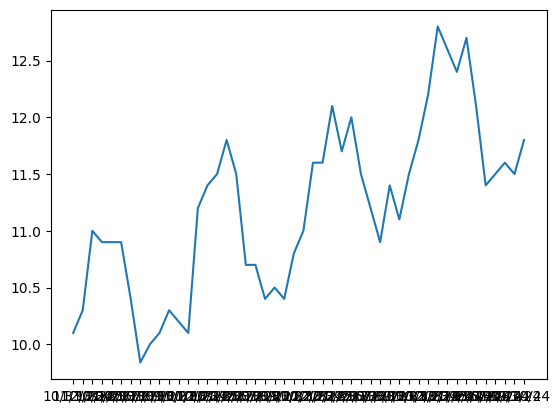

In [191]:
# genrate the plot
# I choosed dates as x-axis and prices as y-axis
plt.plot(natural_gas_df['Dates'], natural_gas_df['Prices'])

### 2. Analyize the JAnuary Monts prices Using Linar Regression

Because it shows linear growth year on year

/tmp/ipykernel_960/1854211789.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  natural_gas_df['Dates'] = pd.to_datetime(natural_gas_df['Dates'])


,Dates,Prices,Month,Year
3,2021-01-31,10.9,1,2021
15,2022-01-31,11.5,1,2022
27,2023-01-31,12.1,1,2023
39,2024-01-31,12.6,1,2024


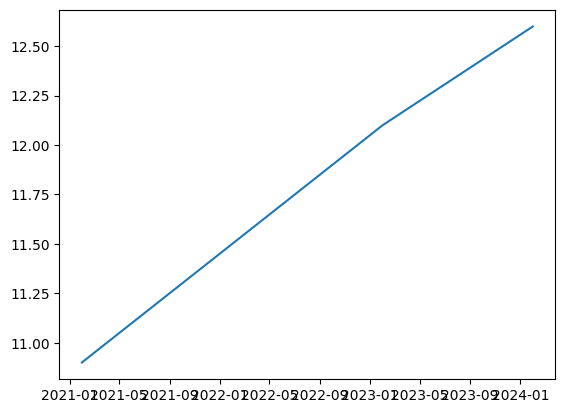

In [192]:
# select only january month prices
natural_gas_df['Dates'] = pd.to_datetime(natural_gas_df['Dates'])

natural_gas_df['Month'] = natural_gas_df['Dates'].dt.month
natural_gas_df['Year'] = natural_gas_df['Dates'].dt.year

# declare the january dataframe obkect
natural_gas_jan = natural_gas_df[natural_gas_df['Month'] == 1]

# declare the plot object of the jan df obect
natural_gas_jan_plot = plt.plot(natural_gas_jan['Dates'], natural_gas_jan['Prices'])

# Show the JAnuary's Price data the Natural GAs
natural_gas_jan

In [193]:
from sklearn.linear_model import LinearRegression

x = np.array(natural_gas_df[natural_gas_df['Month'] == 1]['Year'] ).reshape(-1, 1)
y = np.array(natural_gas_df[natural_gas_df['Month'] == 1] ['Prices'])

reg = LinearRegression().fit(x, y)
reg

LinearRegression()

In [194]:
#
round(float(reg.predict([[2025]])), 4)

/tmp/ipykernel_960/2851572027.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  round(float(reg.predict([[2025]])), 4)


13.2

## 3. Extrapolation for an extra year

### 3.1 Function to predict next year's instrument (natural gas) price

In [195]:
from sklearn.linear_model import LinearRegression

# function to predict next year's instrument (natural gas) price
def next_year_price(next_year):
  "Return a predicted natural ags prices for each month in the following year"

  price_list = []
  for i in np.arange(12):
    x = np.array(natural_gas_df[natural_gas_df['Month'] == 1+i]['Year'] ).reshape(-1, 1)
    y = np.array(natural_gas_df[natural_gas_df['Month'] == 1+i]['Prices'])
    reg = LinearRegression().fit(x, y)
    price_list.append(round(float(reg.predict([[next_year]])), 4))

  return price_list

In [196]:
# predict the next year's natural gas prices "gas_price25"
gas_price25 = next_year_price(2025)
np.array(gas_price25)

/tmp/ipykernel_960/1347388608.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_list.append(round(float(reg.predict([[next_year]])), 4))
/tmp/ipykernel_960/1347388608.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_list.append(round(float(reg.predict([[next_year]])), 4))
/tmp/ipykernel_960/1347388608.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  price_list.append(round(float(reg.predict([[next_year]])), 4))
/tmp/ipykernel_960/1347388608.p

array([13.2 , 12.8 , 13.25, 12.65, 12.08, 11.95, 12.25, 11.9 , 12.45,
       12.85, 13.46, 13.66])

#### 3.2 Get last of each month of the next year

In [197]:
# Function to get next year's months(last date) in ascending order in an array
def get_last_of_each_month(year):
  dates_array = []
  current_date = dt.date(year, 12, 31)      # Start from the last day of the Year
  while current_date.year == year:

    dates_array.append(current_date.strftime('%Y-%m-%d'))
    month = current_date.month
    year = current_date.year

    # Move to the first day of the previous month
    current_date = current_date.replace(year=year, month=month, day=1)

    # Move back one day to get the last day of the current month
    current_date -= dt.timedelta(days=1)

  return dates_array[::-1]

In [198]:
dates_2025 = get_last_of_each_month(2025)
dates_2025

['2025-01-31',
 '2025-02-28',
 '2025-03-31',
 '2025-04-30',
 '2025-05-31',
 '2025-06-30',
 '2025-07-31',
 '2025-08-31',
 '2025-09-30',
 '2025-10-31',
 '2025-11-30',
 '2025-12-31']

### 3.3 EXTRAPOLATION: <i>Projects the next year's price of the natural gas on the last date of each month

In [199]:
# New DAtaFrame of 2025 dates and prices
projected_gas_prices_2025_df = pd.DataFrame({'Dates': dates_2025, 'Prices': gas_price25})

# add moree coloumns
projected_gas_prices_2025_df['Dates'] = pd.to_datetime(projected_gas_prices_2025_df['Dates'])
projected_gas_prices_2025_df['Year'] = projected_gas_prices_2025_df['Dates'].dt.year
projected_gas_prices_2025_df['Month'] = projected_gas_prices_2025_df['Dates'].dt.month

# show the DataFrame
projected_gas_prices_2025_df

,Dates,Prices,Year,Month
0,2025-01-31,13.20,2025,1
1,2025-02-28,12.80,2025,2
2,2025-03-31,13.25,2025,3
3,2025-04-30,12.65,2025,4
4,2025-05-31,12.08,2025,5
5,2025-06-30,11.95,2025,6
6,2025-07-31,12.25,2025,7
7,2025-08-31,11.90,2025,8
8,2025-09-30,12.45,2025,9
9,2025-10-31,12.85,2025,10


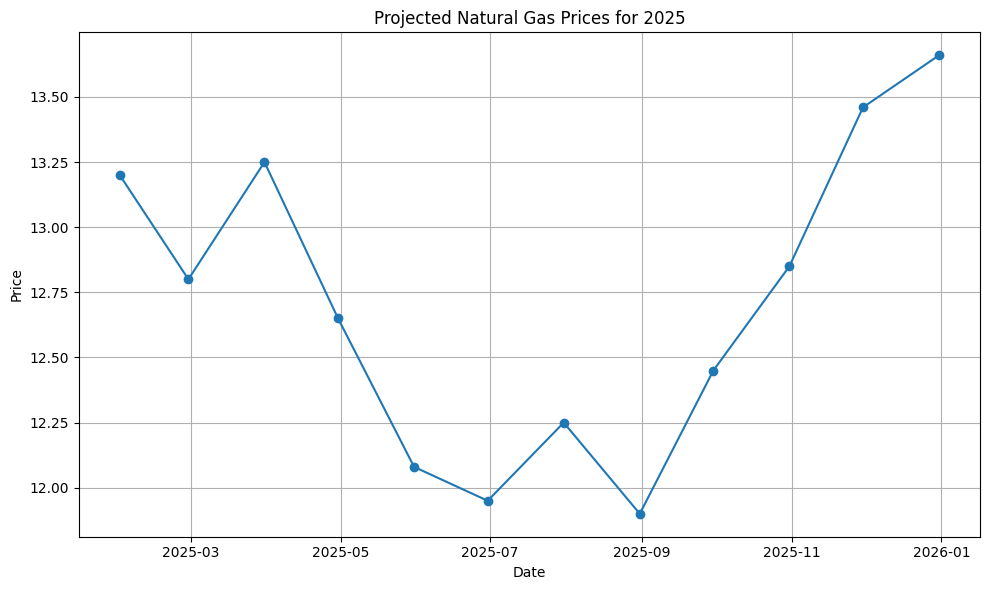

In [200]:
plt.figure(figsize=(10, 6))
plt.plot(projected_gas_prices_2025_df['Dates'], projected_gas_prices_2025_df['Prices'], marker='o')
plt.title('Projected Natural Gas Prices for 2025')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

In [201]:
# Next year prediction ko add/concatinate kardo og datarae mein.

new_predicted_natural_gas_df_extrapolation_using_linear_reg = pd.concat([natural_gas_df_ORIGINAL, projected_gas_prices_2025_df], ignore_index=True)

# add more coloumns
new_predicted_natural_gas_df_extrapolation_using_linear_reg['Dates'] = pd.to_datetime(new_predicted_natural_gas_df_extrapolation_using_linear_reg['Dates'])
new_predicted_natural_gas_df_extrapolation_using_linear_reg['Year'] = new_predicted_natural_gas_df_extrapolation_using_linear_reg['Dates'].dt.year
new_predicted_natural_gas_df_extrapolation_using_linear_reg['Month'] = new_predicted_natural_gas_df_extrapolation_using_linear_reg['Dates'].dt.month

# show the DataFrame
new_predicted_natural_gas_df_extrapolation_using_linear_reg

,Dates,Prices,Month,Year
0,2020-10-31,10.10,10,2020
1,2020-11-30,10.30,11,2020
2,2020-12-31,11.00,12,2020
3,2021-01-31,10.90,1,2021
4,2021-02-28,10.90,2,2021
5,2021-03-31,10.90,3,2021
6,2021-04-30,10.40,4,2021
7,2021-05-31,9.84,5,2021
8,2021-06-30,10.00,6,2021
9,2021-07-31,10.10,7,2021


## Create a funtion to et the natural gas price  for a gieven month and year

In [202]:
def get_gas_price(month, year):
  "Input month and year to get the price"
  print(new_predicted_natural_gas_df_extrapolation_using_linear_reg[ (new_predicted_natural_gas_df_extrapolation_using_linear_reg['Year'] == year) & (new_predicted_natural_gas_df_extrapolation_using_linear_reg['Month'] == month)]['Prices'])

In [203]:
get_gas_price(3, 2025)

50    13.25
Name: Prices, dtype: float64


## Final Analysis

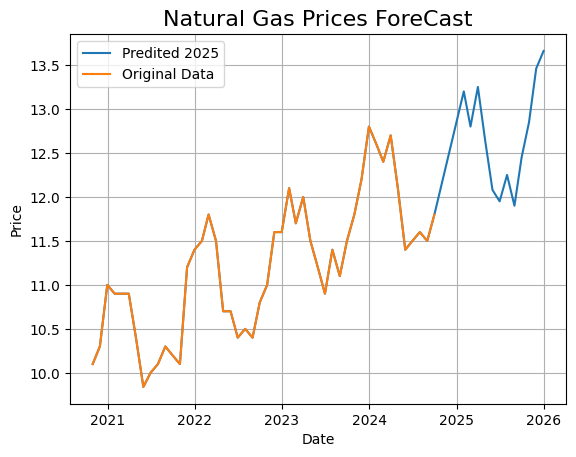

In [204]:
# Prediced Values
plt.plot(new_predicted_natural_gas_df_extrapolation_using_linear_reg['Dates'], new_predicted_natural_gas_df_extrapolation_using_linear_reg['Prices'], label = "Predited 2025")

# Actual Values
plt.plot(natural_gas_df_ORIGINAL['Dates'], natural_gas_df_ORIGINAL['Prices'], label = "Original Data")
plt.xlabel('Date')
plt.ylabel('Price')
plt.title("Natural Gas Prices ForeCast", fontsize=16)
plt.grid(True)
plt.legend()
plt.show()